# TP : Apprentissage Supervisé avec Python

## Atelier 4 : Feature Engineering et Classification

## Imports et configuration initiale

In [1]:
import numpy as np
np.set_printoptions(threshold=10000, suppress=True)
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier, RandomForestClassifier
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_curve, auc, make_scorer
from sklearn.pipeline import Pipeline
import pickle

## 1. Chargement des données et préparation

In [2]:
df = pd.read_csv('Data/credit_scoring.csv', sep=';')

print("Premières lignes du dataset:")
print(df.head())
print("\nInformations sur le dataset:")
print(df.info())

Premières lignes du dataset:
   Seniority  Home  Time   Age  Marital  Records  Job  Expenses  Income  \
0        9.0   1.0  60.0  30.0      0.0      1.0  1.0      73.0   129.0   
1       17.0   1.0  60.0  58.0      1.0      1.0  0.0      48.0   131.0   
2       10.0   0.0  36.0  46.0      0.0      2.0  1.0      90.0   200.0   
3        0.0   1.0  60.0  24.0      1.0      1.0  0.0      63.0   182.0   
4        0.0   1.0  36.0  26.0      1.0      1.0  0.0      46.0   107.0   

   Assets  Debt  Amount   Price  Status  
0     0.0   0.0   800.0   846.0       1  
1     0.0   0.0  1000.0  1658.0       1  
2  3000.0   0.0  2000.0  2985.0       0  
3  2500.0   0.0   900.0  1325.0       1  
4     0.0   0.0   310.0   910.0       1  

Informations sur le dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4375 entries, 0 to 4374
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Seniority  4375 non-null   float64
 1   Home  

In [3]:
data = df.values
X = data[:, :-1]
Y = data[:, -1]

nom_cols = df.columns[:-1].values

print(f"Shape de X: {X.shape}")
print(f"Shape de Y: {Y.shape}")

Shape de X: (4375, 13)
Shape de Y: (4375,)


In [4]:
print(f"Taille de l'échantillon: {X.shape[0]} exemples")
print(f"Nombre de variables: {X.shape[1]}")

unique, counts = np.unique(Y, return_counts=True)
for val, count in zip(unique, counts):
    percentage = (count / len(Y)) * 100
    print(f"Classe {val}: {count} exemples ({percentage:.2f}%)")

Taille de l'échantillon: 4375 exemples
Nombre de variables: 13
Classe 0.0: 1216 exemples (27.79%)
Classe 1.0: 3159 exemples (72.21%)


In [5]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.5, random_state=1)

print(f"Taille du jeu d'entraînement: {X_train.shape[0]}")
print(f"Taille du jeu de test: {X_test.shape[0]}")

Taille du jeu d'entraînement: 2187
Taille du jeu de test: 2188


## 2. Fixer la variable SEED

In [6]:
SEED = 1

## 3. Apprentissage et évaluation de modèles

In [7]:
clfs = {
    'CART': DecisionTreeClassifier(max_depth=3, random_state=SEED),
    'ID3': DecisionTreeClassifier(max_depth=3, criterion='entropy', random_state=SEED),
    'MLP': MLPClassifier(hidden_layer_sizes=(20, 10), random_state=SEED, max_iter=1000),
    'KNN': KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    'Bagging': BaggingClassifier(n_estimators=200, random_state=SEED, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, random_state=SEED),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
}

In [8]:
def evaluate_classifier(clf, X_train, Y_train, X_test, Y_test, clf_name="Classifier"):
    
    # Prédictions
    Y_pred = clf.predict(X_test)
    
    # Matrice de confusion
    cm = confusion_matrix(Y_test, Y_pred)
    print(f"\n{'='*60}")
    print(f"Résultats pour {clf_name}")
    print(f"{'='*60}")
    
    # Affichage textuel de la matrice de confusion
    print("\nMatrice de confusion:")
    print(cm)
    
    # Visualisation graphique de la matrice de confusion
    plt.figure(figsize=(8, 6))
    import seaborn as sns
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['Classe 0', 'Classe 1'], 
                yticklabels=['Classe 0', 'Classe 1'])
    plt.ylabel('Vraie classe')
    plt.xlabel('Classe prédite')
    plt.title(f'Matrice de confusion - {clf_name}')
    plt.tight_layout()
    plt.show()
    
    # Métriques
    accuracy = accuracy_score(Y_test, Y_pred)
    precision = precision_score(Y_test, Y_pred, average='weighted', zero_division=0)
    recall = recall_score(Y_test, Y_pred, average='weighted', zero_division=0)
    
    print(f"\nAccuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    
    best_criterion = max(precision, recall)
    best_criterion_name = "Precision" if precision >= recall else "Recall"
    print(f"Meilleur critère: {best_criterion_name} = {best_criterion:.4f}")
    
    # Courbe ROC
    try:
        if hasattr(clf, 'predict_proba'):
            Y_proba = clf.predict_proba(X_test)
            if len(np.unique(Y_test)) == 2:
                fpr, tpr, _ = roc_curve(Y_test, Y_proba[:, 1])
                roc_auc = auc(fpr, tpr)
                
                plt.figure(figsize=(8, 6))
                plt.plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc:.2f})')
                plt.plot([0, 1], [0, 1], 'k--', label='Random')
                plt.xlabel('False Positive Rate')
                plt.ylabel('True Positive Rate')
                plt.title(f'Courbe ROC - {clf_name}')
                plt.legend()
                plt.grid(True)
                plt.show()
    except Exception as e:
        print(f"Impossible de tracer la courbe ROC: {e}")
    
    score_final = (accuracy + best_criterion) / 2
    print(f"\nScore final (accuracy + {best_criterion_name})/2: {score_final:.4f}")
    
    return score_final

In [9]:
def run_classifiers_train_test(clfs, X_train, Y_train, X_test, Y_test):
    results = {}
    best_score = 0
    best_clf_name = None
    best_clf = None
    
    for clf_name, clf in clfs.items():
        print(f"\nEntraînement de {clf_name}...")
        clf.fit(X_train, Y_train)
        score = evaluate_classifier(clf, X_train, Y_train, X_test, Y_test, clf_name)
        results[clf_name] = score
        
        if score > best_score:
            best_score = score
            best_clf_name = clf_name
            best_clf = clf
    
    print("COMPARAISON DES SCORES FINAUX")
    for clf_name, score in sorted(results.items(), key=lambda x: x[1], reverse=True):
        print(f"{clf_name:15s}: {score:.4f}")
    
    print(f"\nMeilleur modèle: {best_clf_name} avec un score de {best_score:.4f}")
    
    return best_clf, best_clf_name, results

ÉVALUATION SUR DONNÉES ORIGINALES

Entraînement de CART...

Résultats pour CART

Matrice de confusion:
[[ 167  437]
 [  87 1497]]


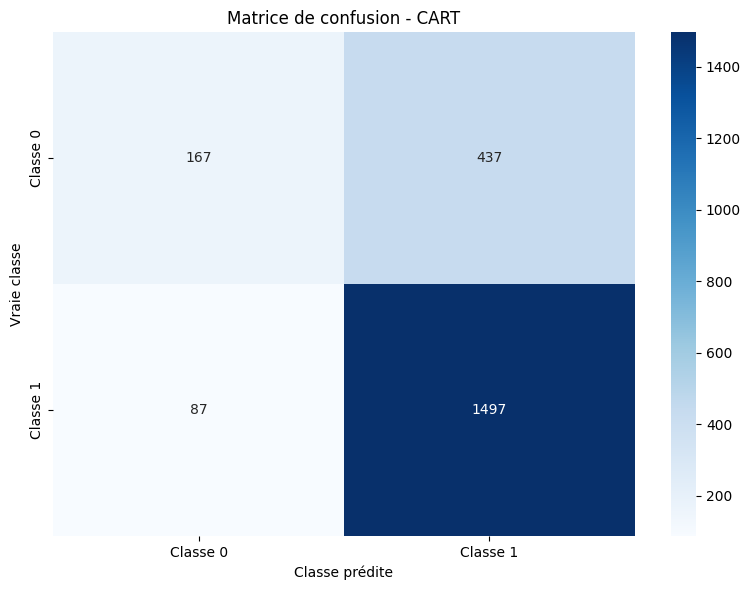


Accuracy: 0.7605
Precision: 0.7419
Recall: 0.7605
Meilleur critère: Recall = 0.7605


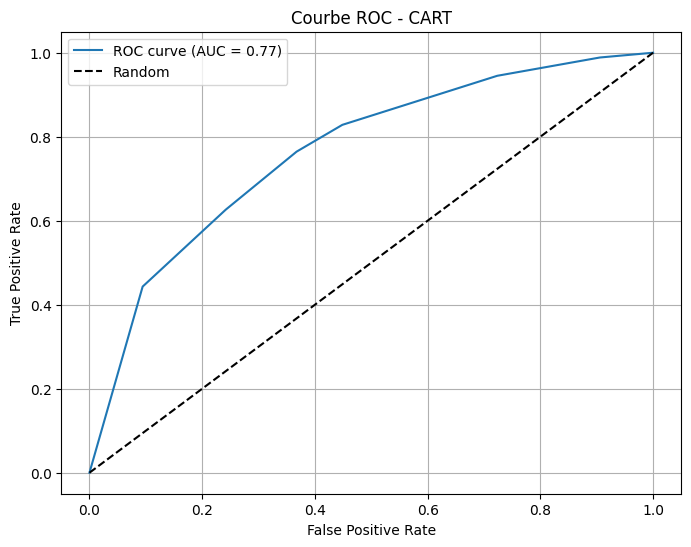


Score final (accuracy + Recall)/2: 0.7605

Entraînement de ID3...

Résultats pour ID3

Matrice de confusion:
[[ 167  437]
 [  92 1492]]


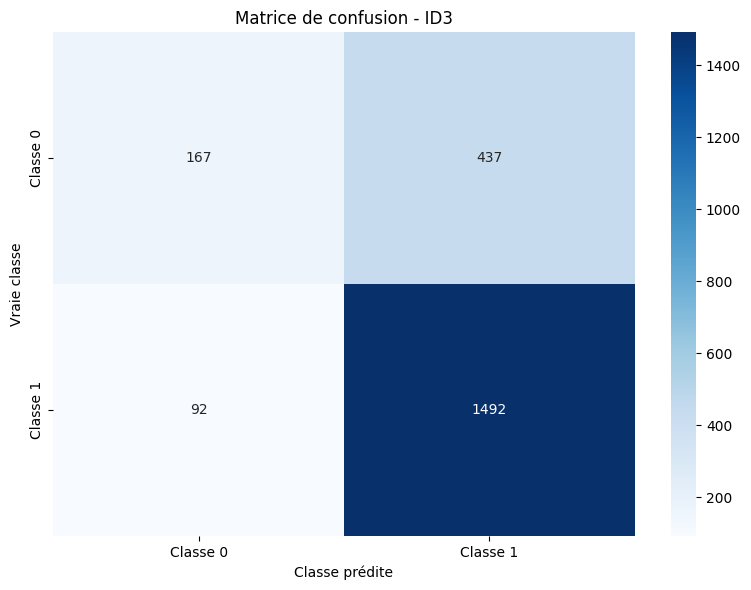


Accuracy: 0.7582
Precision: 0.7379
Recall: 0.7582
Meilleur critère: Recall = 0.7582


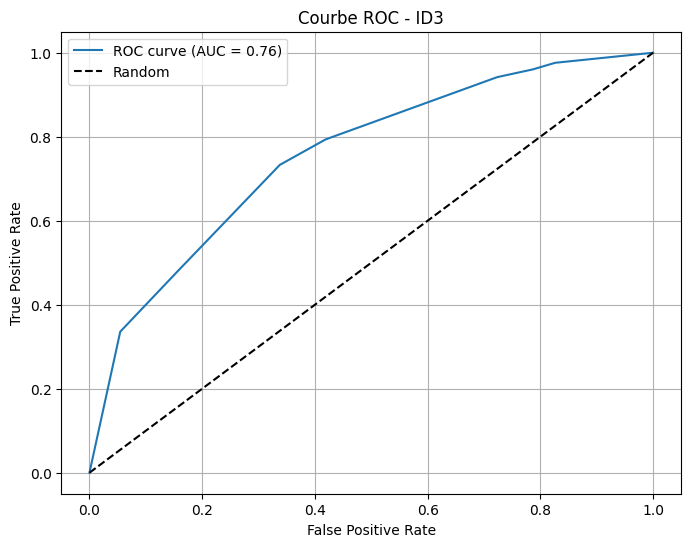


Score final (accuracy + Recall)/2: 0.7582

Entraînement de MLP...

Résultats pour MLP

Matrice de confusion:
[[ 407  197]
 [ 572 1012]]


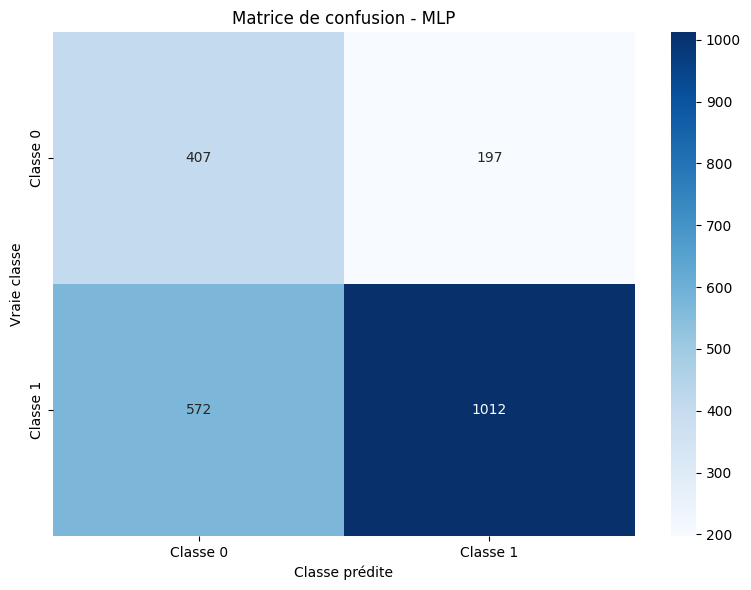


Accuracy: 0.6485
Precision: 0.7207
Recall: 0.6485
Meilleur critère: Precision = 0.7207


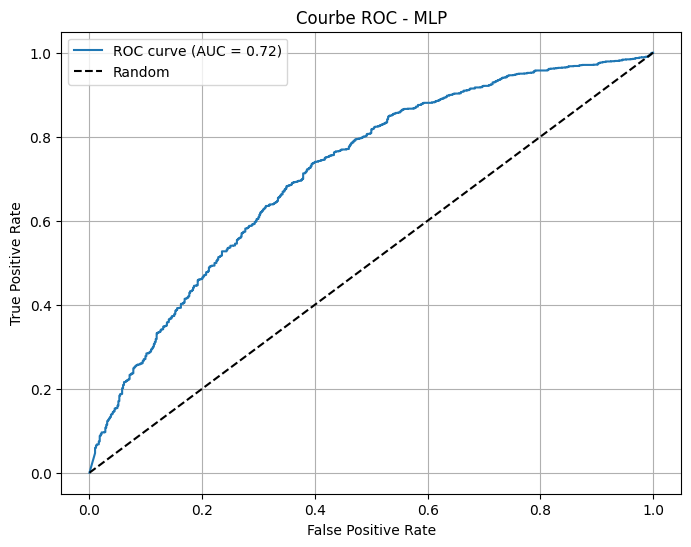


Score final (accuracy + Precision)/2: 0.6846

Entraînement de KNN...

Résultats pour KNN

Matrice de confusion:
[[ 189  415]
 [ 187 1397]]


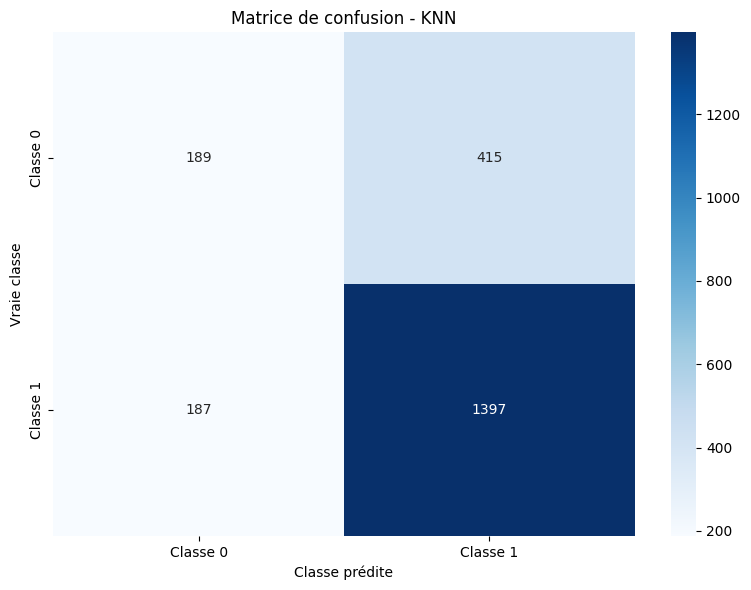


Accuracy: 0.7249
Precision: 0.6969
Recall: 0.7249
Meilleur critère: Recall = 0.7249


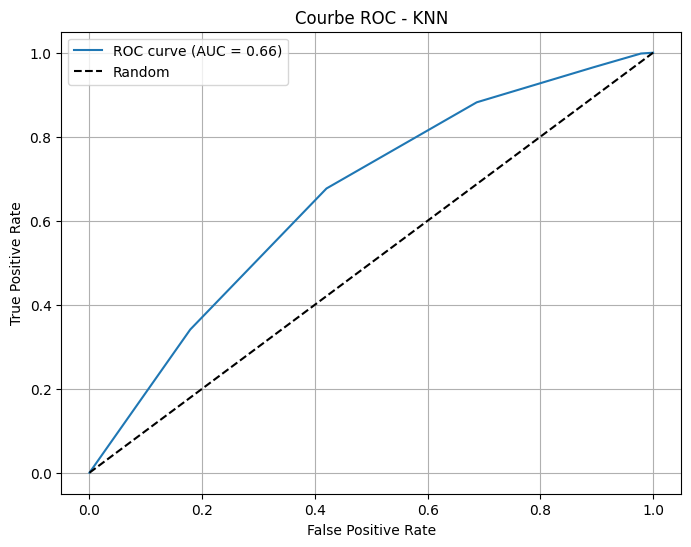


Score final (accuracy + Recall)/2: 0.7249

Entraînement de Bagging...

Résultats pour Bagging

Matrice de confusion:
[[ 328  276]
 [ 194 1390]]


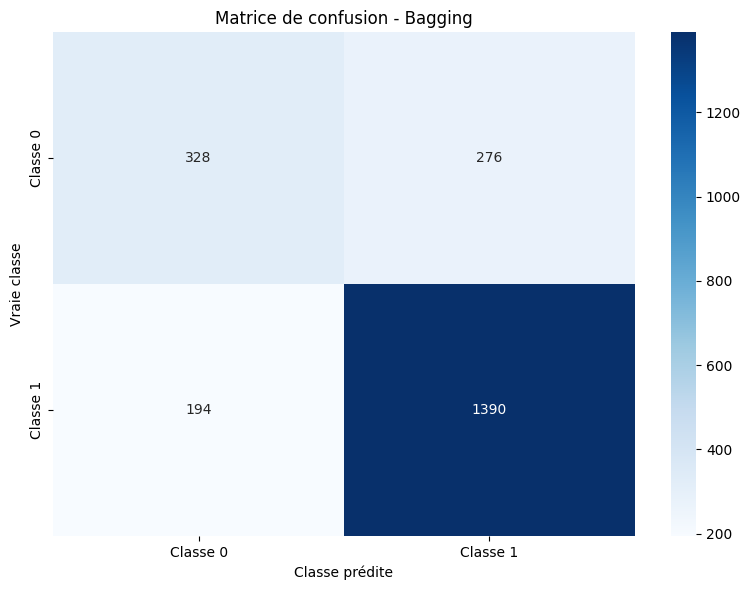


Accuracy: 0.7852
Precision: 0.7775
Recall: 0.7852
Meilleur critère: Recall = 0.7852


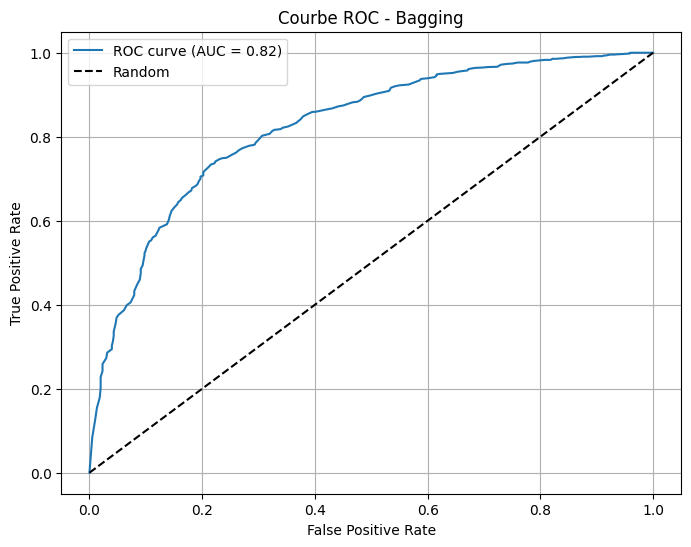


Score final (accuracy + Recall)/2: 0.7852

Entraînement de AdaBoost...

Résultats pour AdaBoost

Matrice de confusion:
[[ 306  298]
 [ 161 1423]]


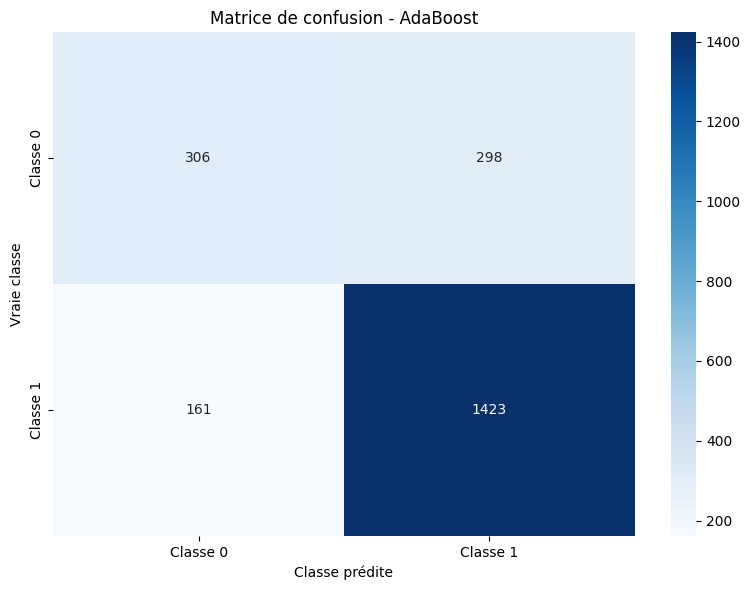


Accuracy: 0.7902
Precision: 0.7795
Recall: 0.7902
Meilleur critère: Recall = 0.7902


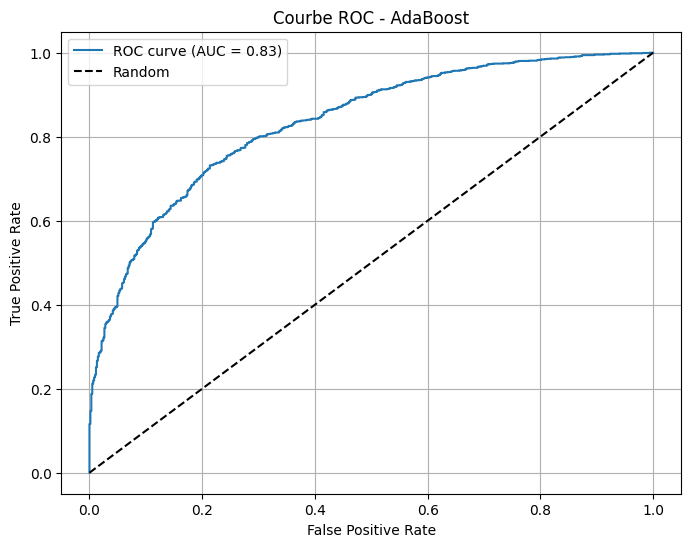


Score final (accuracy + Recall)/2: 0.7902

Entraînement de RandomForest...

Résultats pour RandomForest

Matrice de confusion:
[[ 302  302]
 [ 155 1429]]


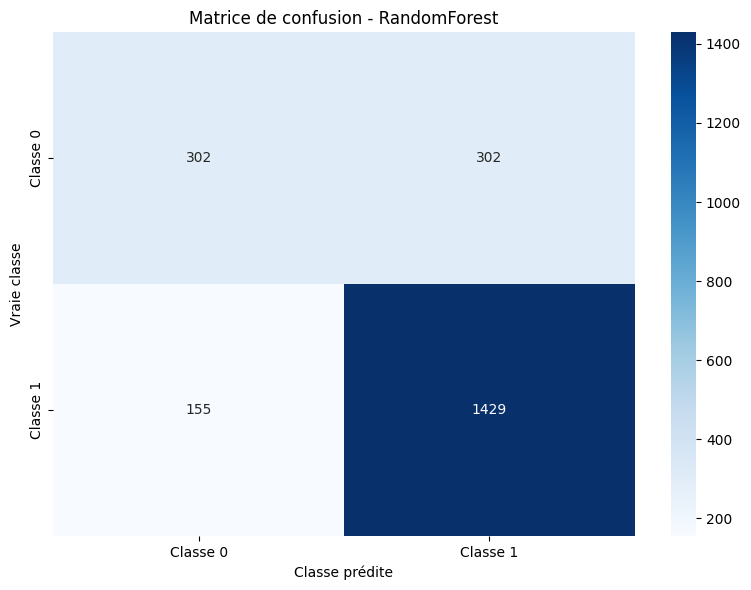


Accuracy: 0.7911
Precision: 0.7801
Recall: 0.7911
Meilleur critère: Recall = 0.7911


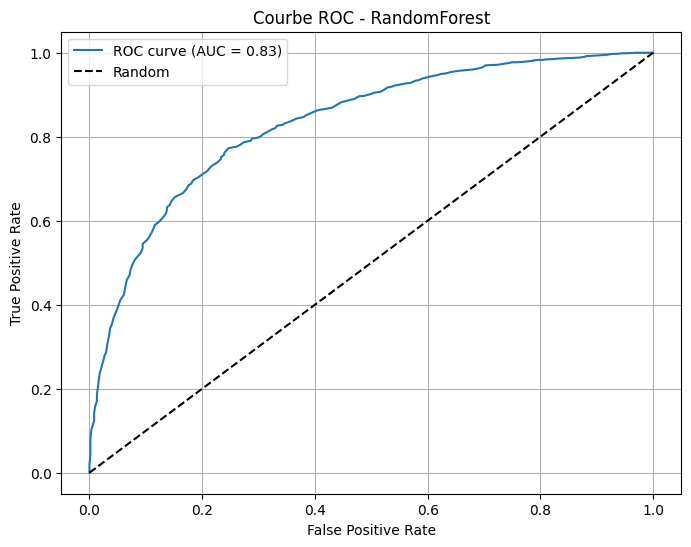


Score final (accuracy + Recall)/2: 0.7911
COMPARAISON DES SCORES FINAUX
RandomForest   : 0.7911
AdaBoost       : 0.7902
Bagging        : 0.7852
CART           : 0.7605
ID3            : 0.7582
KNN            : 0.7249
MLP            : 0.6846

Meilleur modèle: RandomForest avec un score de 0.7911


In [10]:
print("ÉVALUATION SUR DONNÉES ORIGINALES")
best_clf_original, best_name_original, results_original = run_classifiers_train_test(
    clfs, X_train, Y_train, X_test, Y_test
)

## 4. Normalisation des variables continues

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Données normalisées!")
print(f"Moyenne des features (train): {X_train_scaled.mean(axis=0)[:5]}...")
print(f"Écart-type des features (train): {X_train_scaled.std(axis=0)[:5]}...")

Données normalisées!
Moyenne des features (train): [ 0.  0. -0. -0.  0.]...
Écart-type des features (train): [1. 1. 1. 1. 1.]...


ÉVALUATION SUR DONNÉES NORMALISÉES

Entraînement de CART...

Résultats pour CART

Matrice de confusion:
[[ 167  437]
 [  87 1497]]


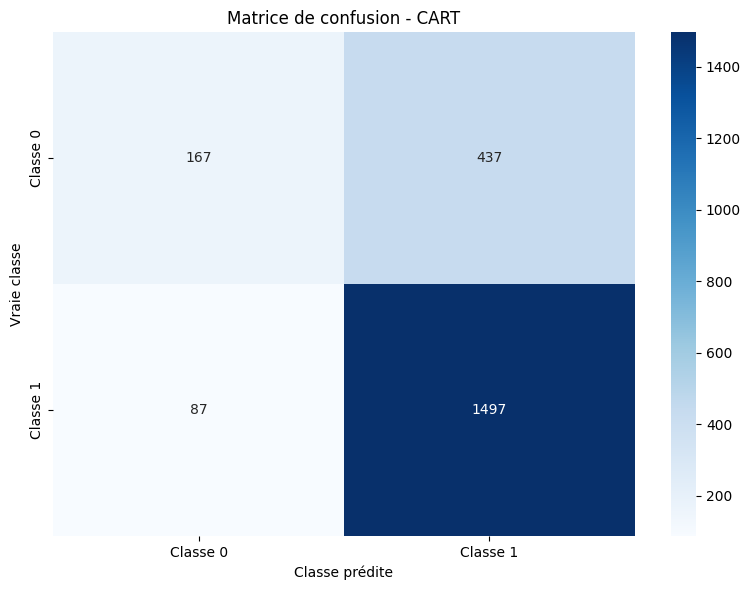


Accuracy: 0.7605
Precision: 0.7419
Recall: 0.7605
Meilleur critère: Recall = 0.7605


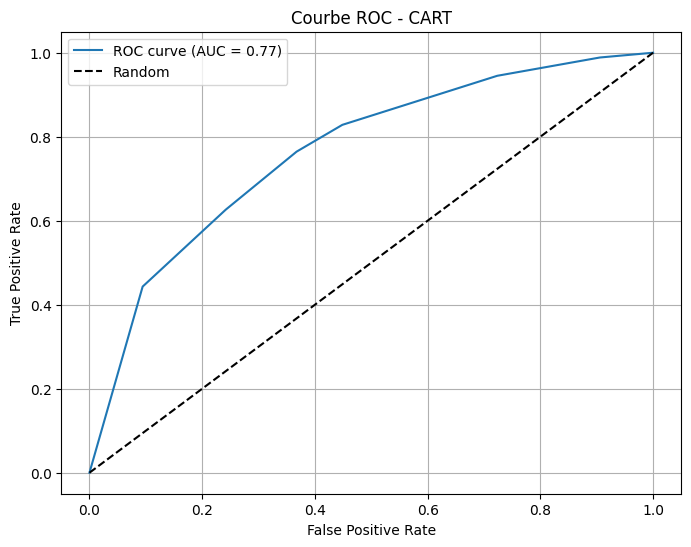


Score final (accuracy + Recall)/2: 0.7605

Entraînement de ID3...

Résultats pour ID3

Matrice de confusion:
[[ 167  437]
 [  92 1492]]


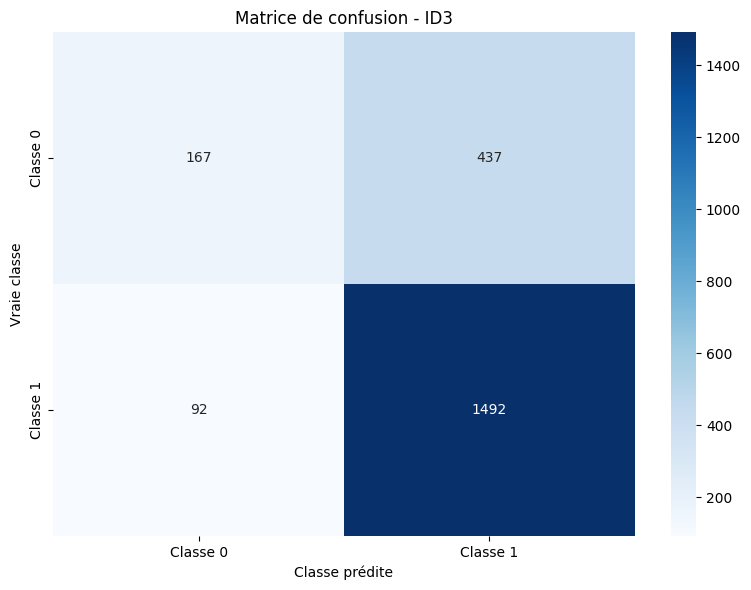


Accuracy: 0.7582
Precision: 0.7379
Recall: 0.7582
Meilleur critère: Recall = 0.7582


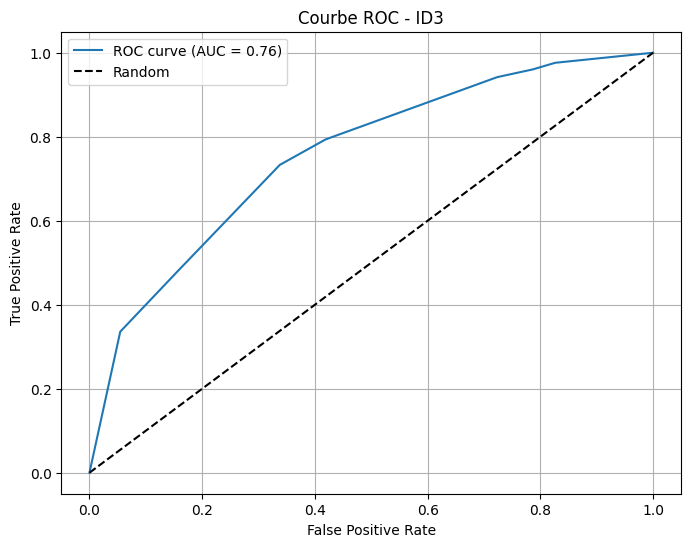


Score final (accuracy + Recall)/2: 0.7582

Entraînement de MLP...

Résultats pour MLP

Matrice de confusion:
[[ 348  256]
 [ 278 1306]]


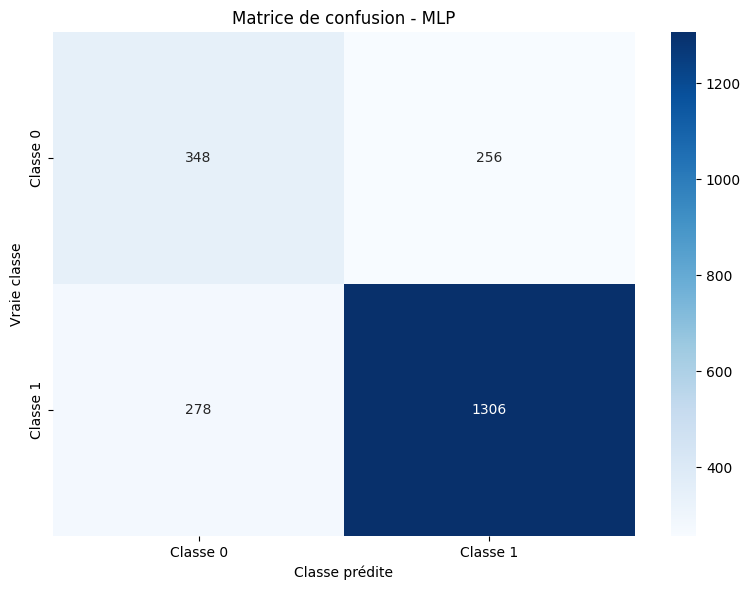


Accuracy: 0.7559
Precision: 0.7588
Recall: 0.7559
Meilleur critère: Precision = 0.7588


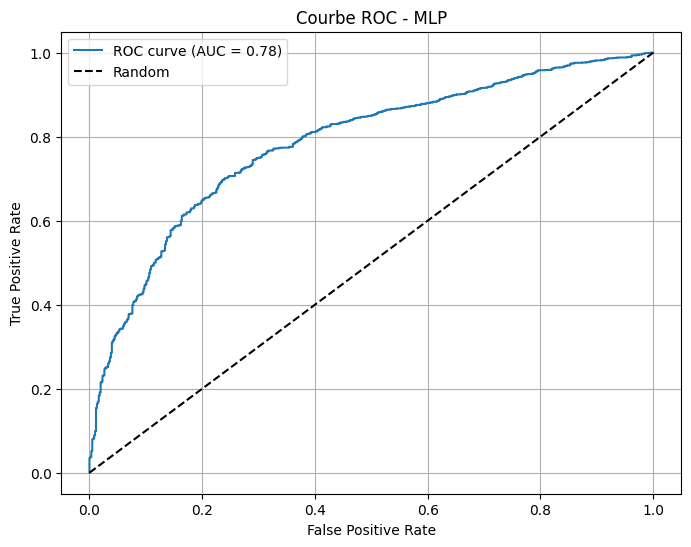


Score final (accuracy + Precision)/2: 0.7574

Entraînement de KNN...

Résultats pour KNN

Matrice de confusion:
[[ 286  318]
 [ 223 1361]]


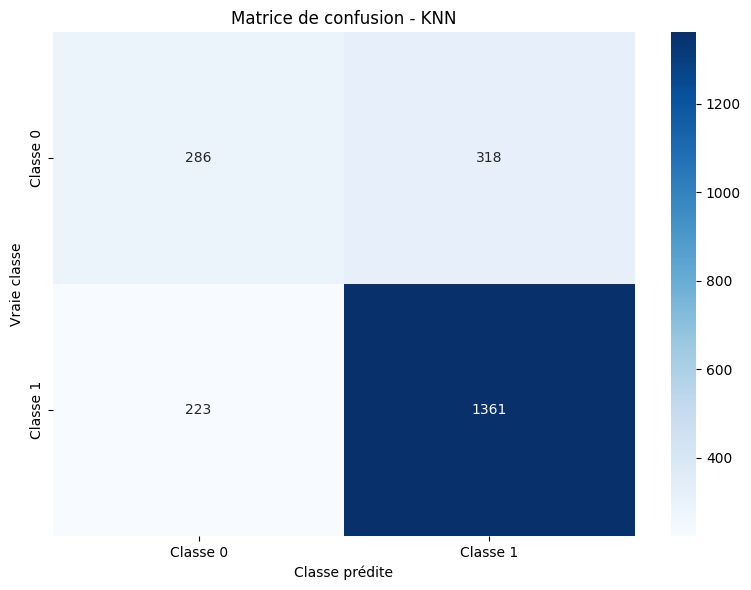


Accuracy: 0.7527
Precision: 0.7419
Recall: 0.7527
Meilleur critère: Recall = 0.7527


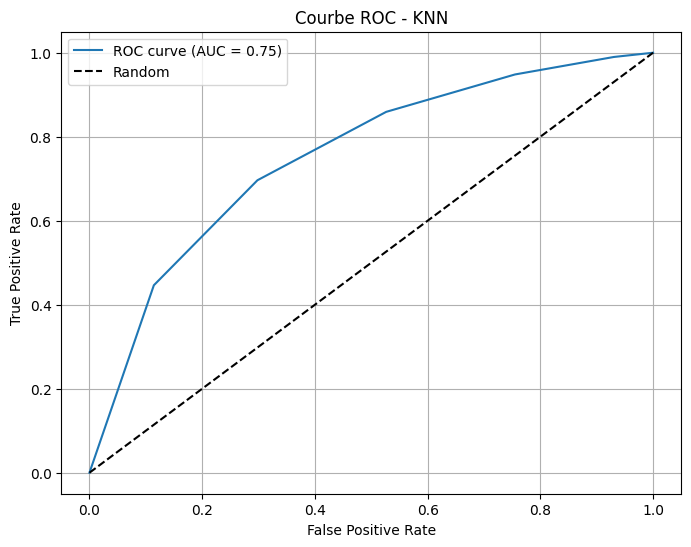


Score final (accuracy + Recall)/2: 0.7527

Entraînement de Bagging...

Résultats pour Bagging

Matrice de confusion:
[[ 328  276]
 [ 194 1390]]


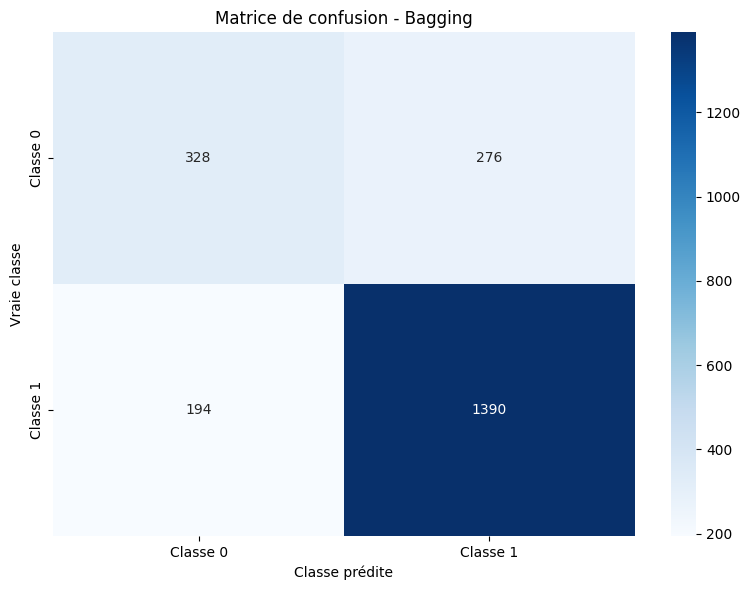


Accuracy: 0.7852
Precision: 0.7775
Recall: 0.7852
Meilleur critère: Recall = 0.7852


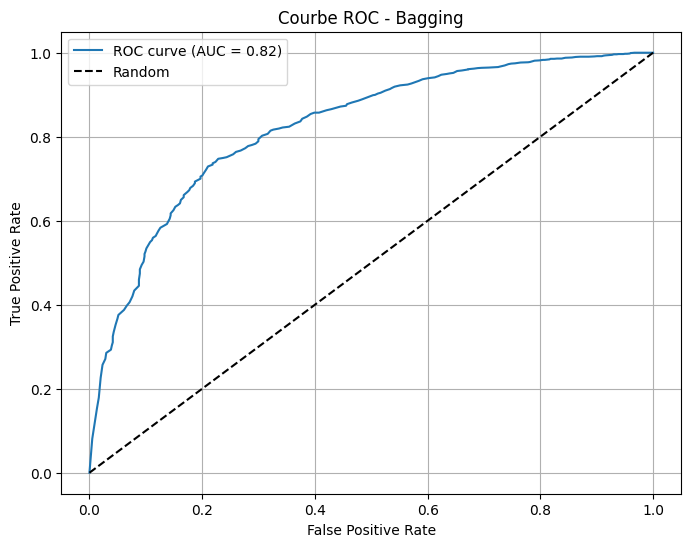


Score final (accuracy + Recall)/2: 0.7852

Entraînement de AdaBoost...

Résultats pour AdaBoost

Matrice de confusion:
[[ 306  298]
 [ 161 1423]]


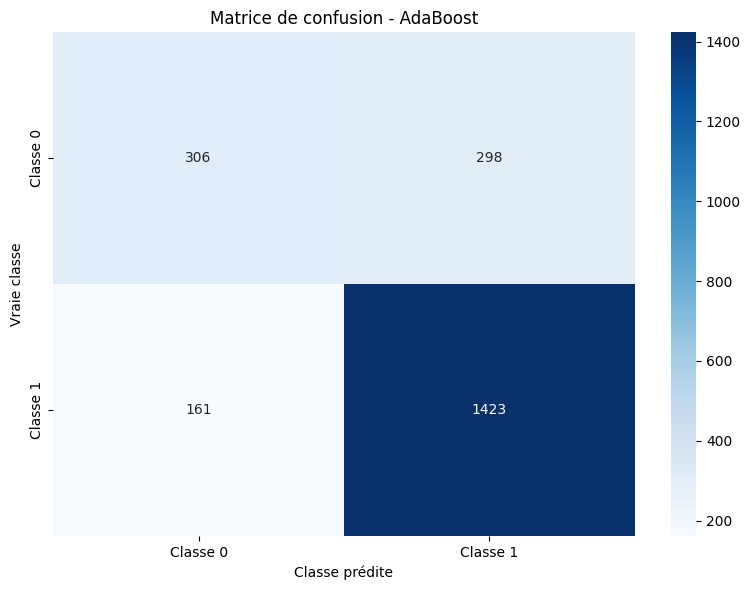


Accuracy: 0.7902
Precision: 0.7795
Recall: 0.7902
Meilleur critère: Recall = 0.7902


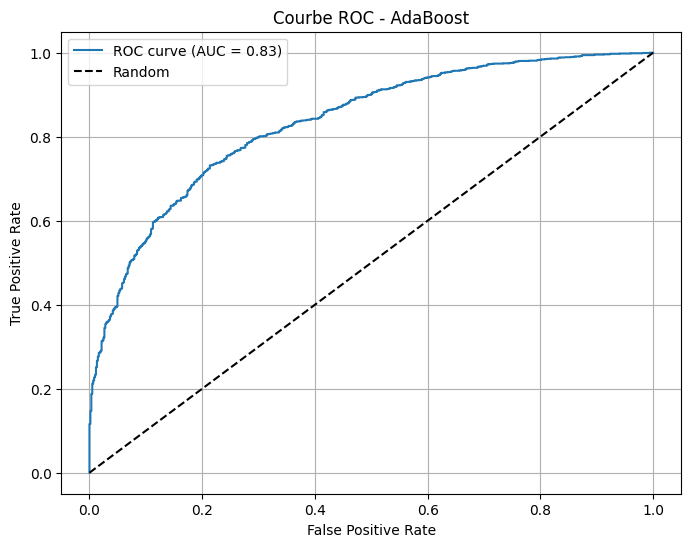


Score final (accuracy + Recall)/2: 0.7902

Entraînement de RandomForest...

Résultats pour RandomForest

Matrice de confusion:
[[ 301  303]
 [ 157 1427]]


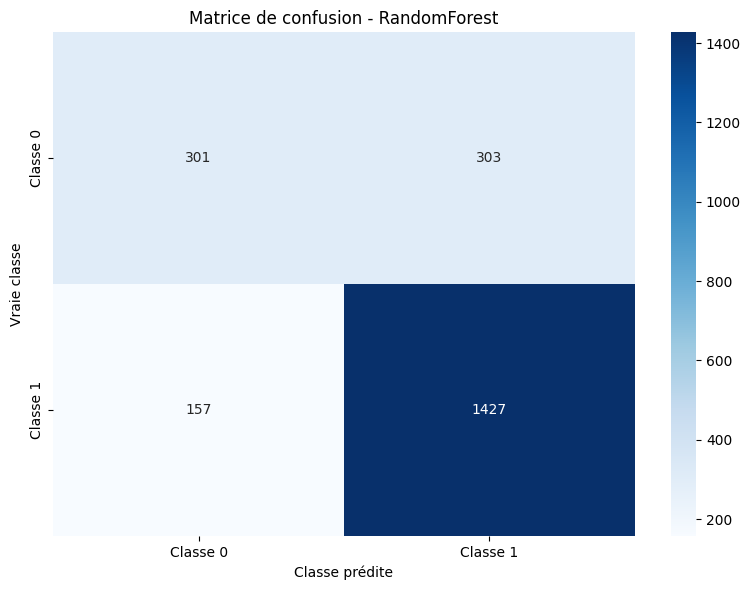


Accuracy: 0.7898
Precision: 0.7786
Recall: 0.7898
Meilleur critère: Recall = 0.7898


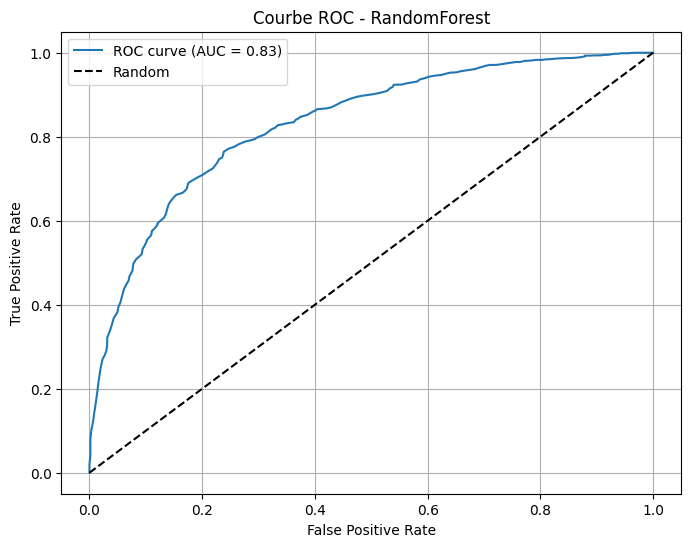


Score final (accuracy + Recall)/2: 0.7898
COMPARAISON DES SCORES FINAUX
AdaBoost       : 0.7902
RandomForest   : 0.7898
Bagging        : 0.7852
CART           : 0.7605
ID3            : 0.7582
MLP            : 0.7574
KNN            : 0.7527

Meilleur modèle: AdaBoost avec un score de 0.7902


In [12]:
print("ÉVALUATION SUR DONNÉES NORMALISÉES")
best_clf_scaled, best_name_scaled, results_scaled = run_classifiers_train_test(
    clfs, X_train_scaled, Y_train, X_test_scaled, Y_test
)

In [13]:
print(f"{'Classifier':<15} {'Original':<12} {'Normalisé':<12} {'Différence':<12}")
for clf_name in clfs.keys():
    diff = results_scaled[clf_name] - results_original[clf_name]
    print(f"{clf_name:<15} {results_original[clf_name]:<12.4f} {results_scaled[clf_name]:<12.4f} {diff:<12.4f}")

Classifier      Original     Normalisé    Différence  
CART            0.7605       0.7605       0.0000      
ID3             0.7582       0.7582       0.0000      
MLP             0.6846       0.7574       0.0727      
KNN             0.7249       0.7527       0.0279      
Bagging         0.7852       0.7852       0.0000      
AdaBoost        0.7902       0.7902       0.0000      
RandomForest    0.7911       0.7898       -0.0014     


## 5. Création de nouvelles variables avec ACP

In [14]:
pca = PCA(n_components=3, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Variance expliquée par chaque composante: {pca.explained_variance_ratio_}")
print(f"Variance totale expliquée: {pca.explained_variance_ratio_.sum():.4f}")

X_train_with_pca = np.concatenate([X_train_scaled, X_train_pca], axis=1)
X_test_with_pca = np.concatenate([X_test_scaled, X_test_pca], axis=1)

print(f"\nShape des données avec PCA: {X_train_with_pca.shape}")

Variance expliquée par chaque composante: [0.18820572 0.14667046 0.10648009]
Variance totale expliquée: 0.4414

Shape des données avec PCA: (2187, 16)


ÉVALUATION SUR DONNÉES NORMALISÉES + PCA

Entraînement de CART...

Résultats pour CART

Matrice de confusion:
[[ 167  437]
 [  87 1497]]


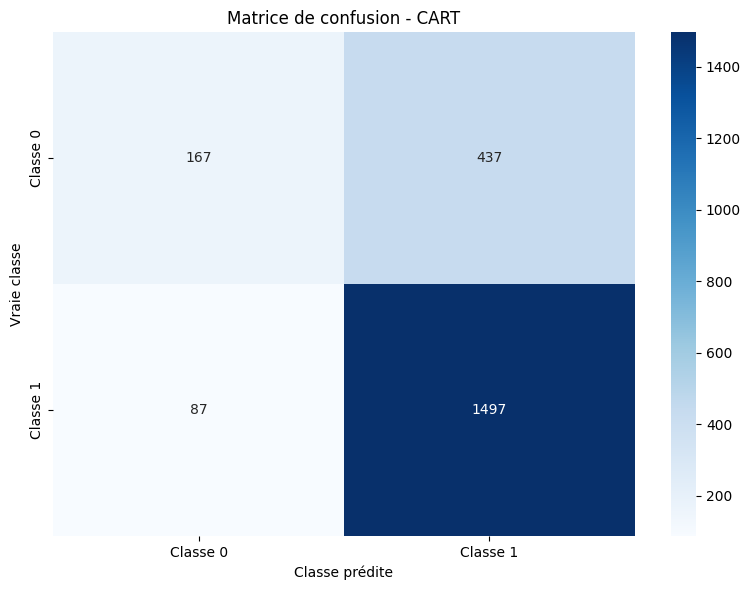


Accuracy: 0.7605
Precision: 0.7419
Recall: 0.7605
Meilleur critère: Recall = 0.7605


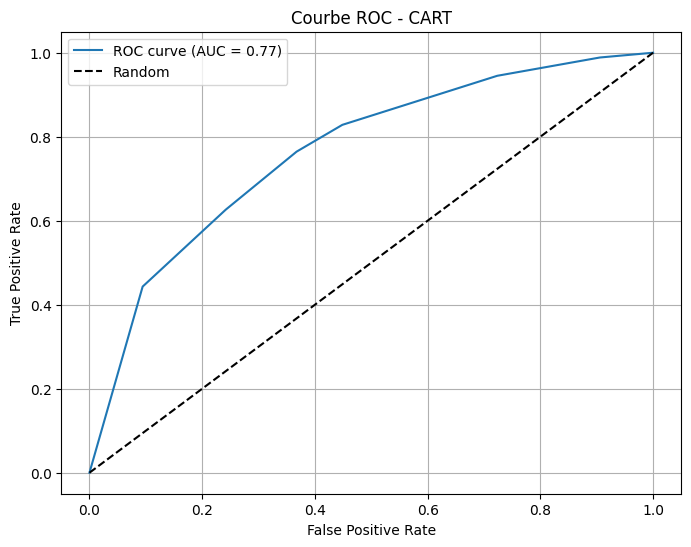


Score final (accuracy + Recall)/2: 0.7605

Entraînement de ID3...

Résultats pour ID3

Matrice de confusion:
[[ 167  437]
 [  92 1492]]


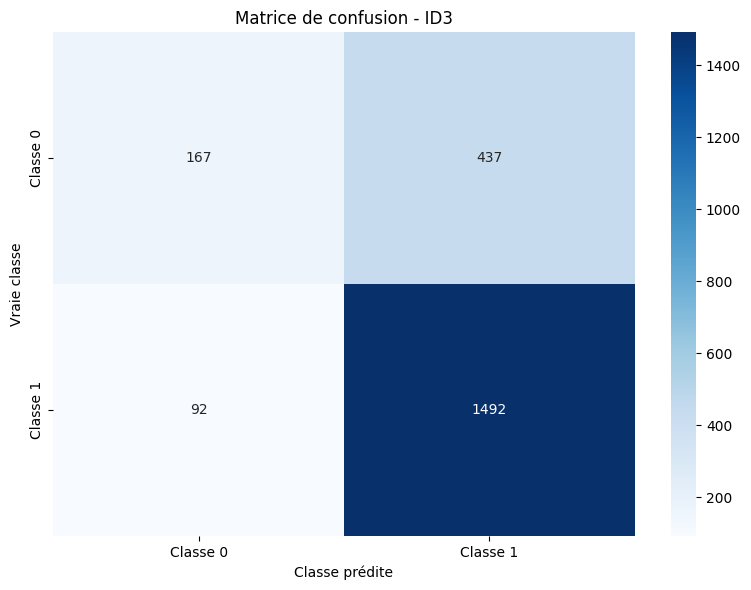


Accuracy: 0.7582
Precision: 0.7379
Recall: 0.7582
Meilleur critère: Recall = 0.7582


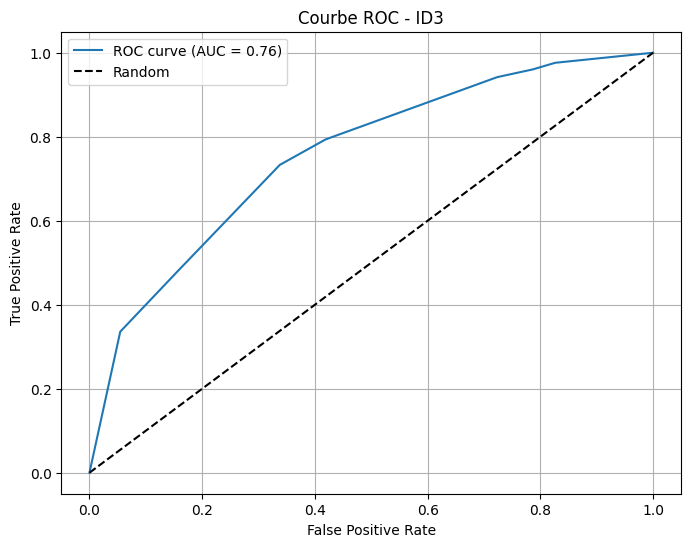


Score final (accuracy + Recall)/2: 0.7582

Entraînement de MLP...

Résultats pour MLP

Matrice de confusion:
[[ 337  267]
 [ 229 1355]]


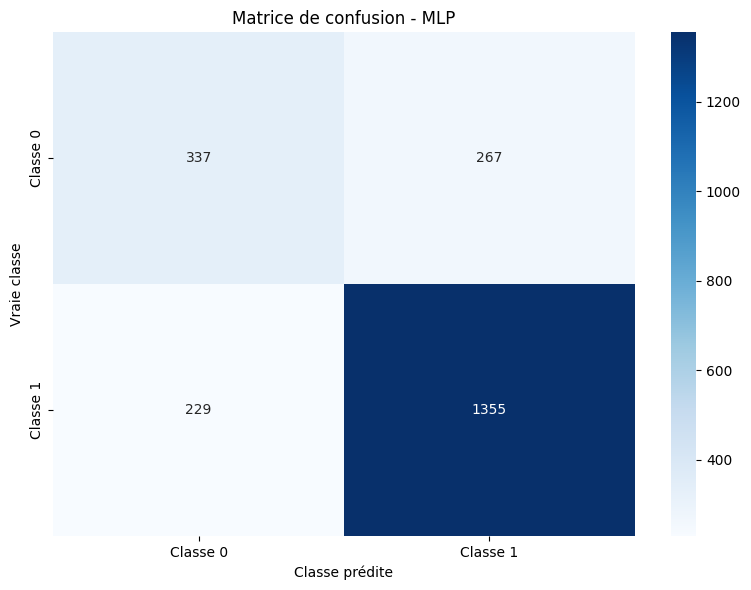


Accuracy: 0.7733
Precision: 0.7691
Recall: 0.7733
Meilleur critère: Recall = 0.7733


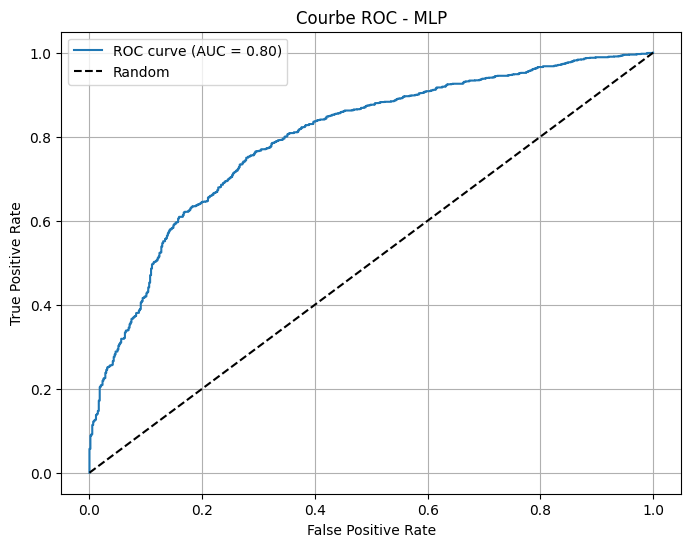


Score final (accuracy + Recall)/2: 0.7733

Entraînement de KNN...

Résultats pour KNN

Matrice de confusion:
[[ 283  321]
 [ 212 1372]]


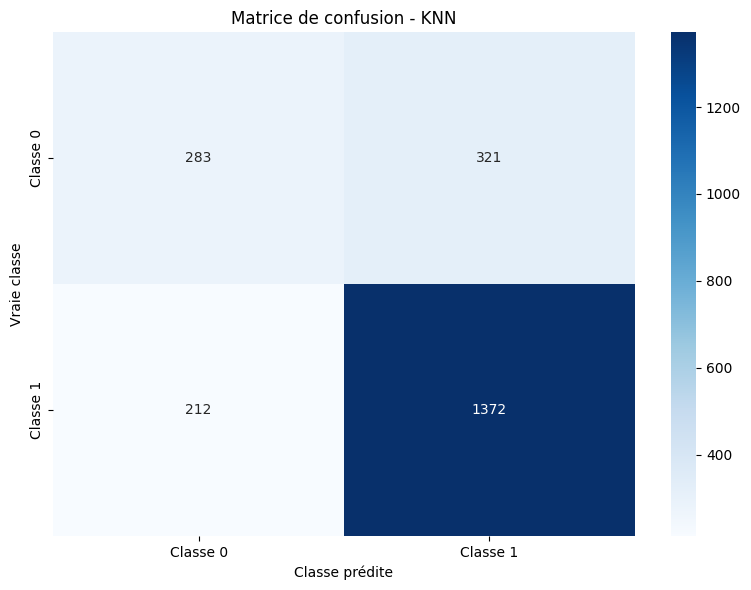


Accuracy: 0.7564
Precision: 0.7445
Recall: 0.7564
Meilleur critère: Recall = 0.7564


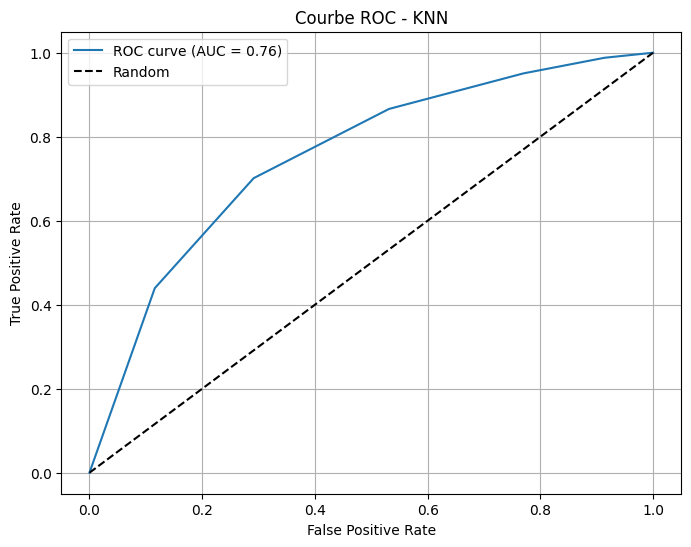


Score final (accuracy + Recall)/2: 0.7564

Entraînement de Bagging...

Résultats pour Bagging

Matrice de confusion:
[[ 322  282]
 [ 177 1407]]


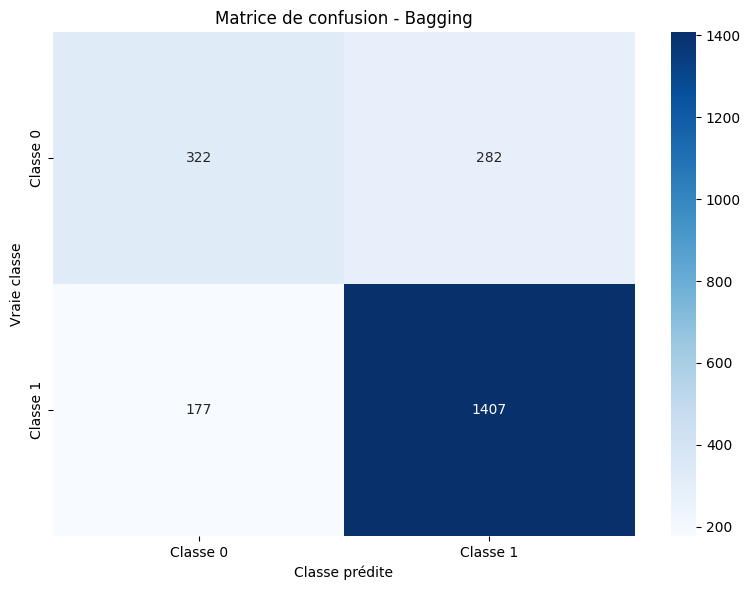


Accuracy: 0.7902
Precision: 0.7812
Recall: 0.7902
Meilleur critère: Recall = 0.7902


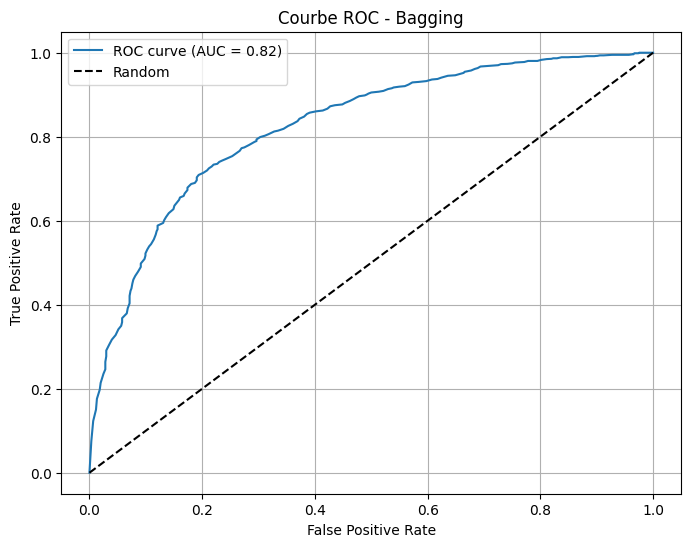


Score final (accuracy + Recall)/2: 0.7902

Entraînement de AdaBoost...

Résultats pour AdaBoost

Matrice de confusion:
[[ 305  299]
 [ 149 1435]]


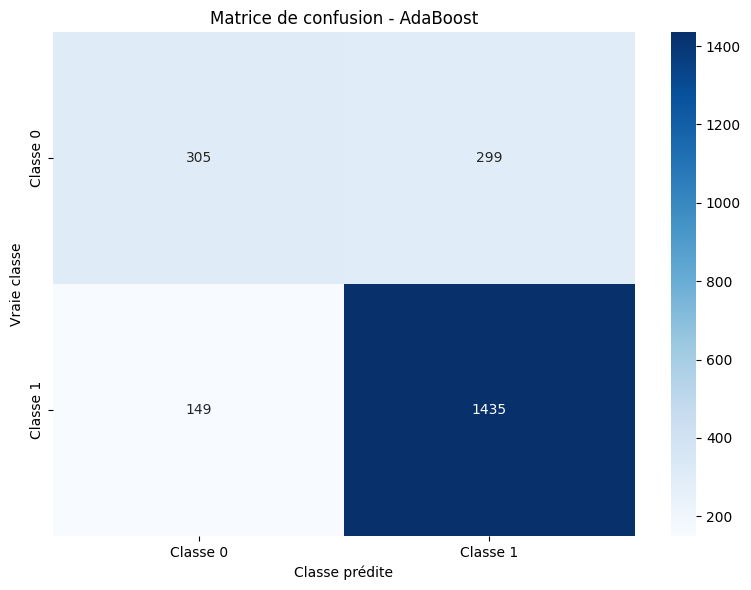


Accuracy: 0.7952
Precision: 0.7846
Recall: 0.7952
Meilleur critère: Recall = 0.7952


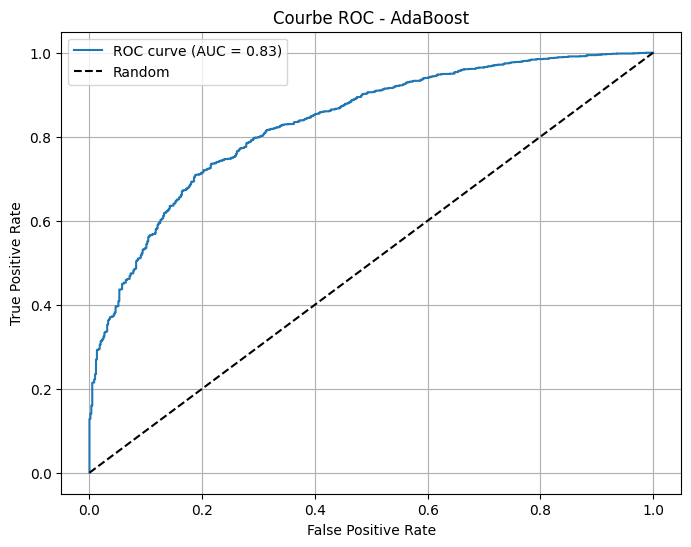


Score final (accuracy + Recall)/2: 0.7952

Entraînement de RandomForest...

Résultats pour RandomForest

Matrice de confusion:
[[ 314  290]
 [ 149 1435]]


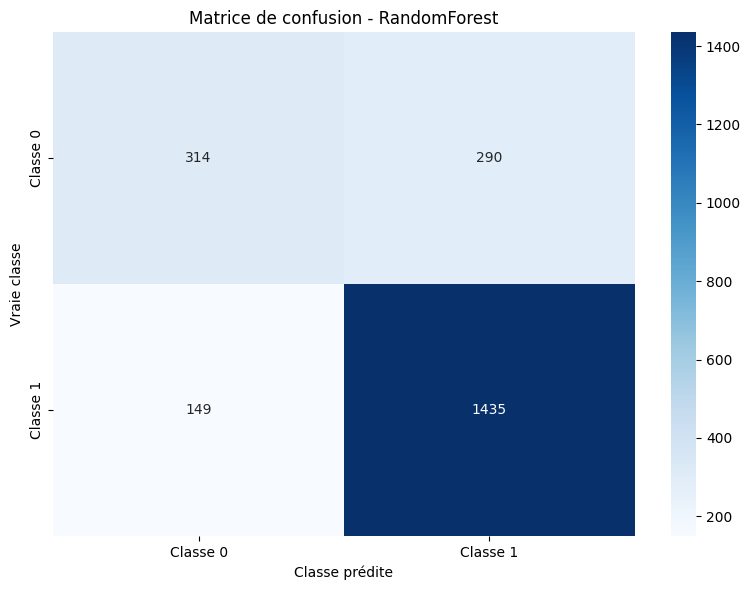


Accuracy: 0.7994
Precision: 0.7895
Recall: 0.7994
Meilleur critère: Recall = 0.7994


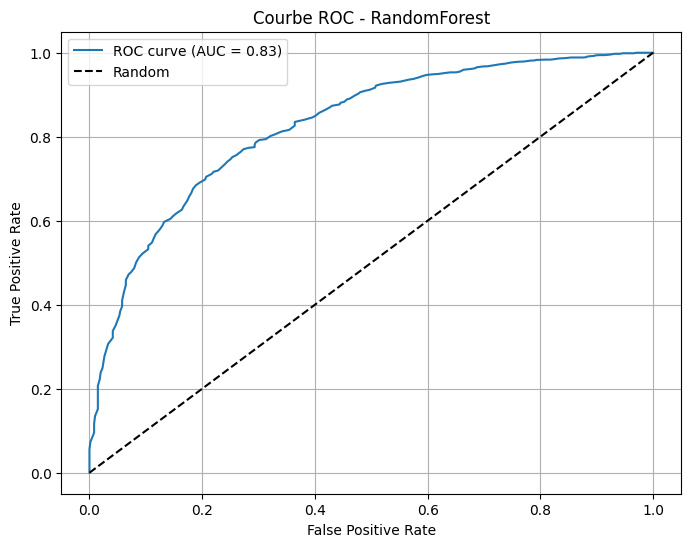


Score final (accuracy + Recall)/2: 0.7994
COMPARAISON DES SCORES FINAUX
RandomForest   : 0.7994
AdaBoost       : 0.7952
Bagging        : 0.7902
MLP            : 0.7733
CART           : 0.7605
ID3            : 0.7582
KNN            : 0.7564

Meilleur modèle: RandomForest avec un score de 0.7994


In [15]:
print("ÉVALUATION SUR DONNÉES NORMALISÉES + PCA")
best_clf_pca, best_name_pca, results_pca = run_classifiers_train_test(
    clfs, X_train_with_pca, Y_train, X_test_with_pca, Y_test
)

## 6. Validation croisée (Cross-Validation)

In [16]:
def custom_score(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    return (acc + prec) / 2

custom_scorer = make_scorer(custom_score)

In [17]:
def run_classifiers_cv(clfs, X, Y, cv_splits=10):
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=SEED)
    results = {}
    
    print(f"\nValidation croisée avec {cv_splits} folds")
    print("="*70)
    
    for clf_name, clf in clfs.items():
        cv_scores = cross_val_score(clf, X, Y, cv=kf, scoring=custom_scorer, n_jobs=-1)
        mean_score = np.mean(cv_scores)
        std_score = np.std(cv_scores)
        results[clf_name] = {'mean': mean_score, 'std': std_score, 'scores': cv_scores}
        print(f"{clf_name:<15} : {mean_score:.4f} +/- {std_score:.4f}")
    
    best_clf_name = max(results.items(), key=lambda x: x[1]['mean'])[0]
    print(f"\nMeilleur algorithme en CV: {best_clf_name}")
    
    return results

In [18]:
print("VALIDATION CROISÉE - DONNÉES ORIGINALES")
cv_results_original = run_classifiers_cv(clfs, X, Y)

VALIDATION CROISÉE - DONNÉES ORIGINALES

Validation croisée avec 10 folds
CART            : 0.7479 +/- 0.0213
ID3             : 0.7522 +/- 0.0184
MLP             : 0.6889 +/- 0.0462
KNN             : 0.7069 +/- 0.0232
Bagging         : 0.7744 +/- 0.0193
AdaBoost        : 0.7897 +/- 0.0143
RandomForest    : 0.7807 +/- 0.0170

Meilleur algorithme en CV: AdaBoost


In [19]:
print("VALIDATION CROISÉE - DONNÉES NORMALISÉES")
X_scaled_full = StandardScaler().fit_transform(X)
cv_results_scaled = run_classifiers_cv(clfs, X_scaled_full, Y)

VALIDATION CROISÉE - DONNÉES NORMALISÉES

Validation croisée avec 10 folds
CART            : 0.7479 +/- 0.0213
ID3             : 0.7522 +/- 0.0184
MLP             : 0.7735 +/- 0.0193
KNN             : 0.7534 +/- 0.0210
Bagging         : 0.7734 +/- 0.0191
AdaBoost        : 0.7897 +/- 0.0143
RandomForest    : 0.7808 +/- 0.0179

Meilleur algorithme en CV: AdaBoost


In [20]:
print("VALIDATION CROISÉE - DONNÉES NORMALISÉES + PCA")
pca_full = PCA(n_components=3, random_state=SEED)
X_pca_full = pca_full.fit_transform(X_scaled_full)
X_with_pca_full = np.concatenate([X_scaled_full, X_pca_full], axis=1)
cv_results_pca = run_classifiers_cv(clfs, X_with_pca_full, Y)

VALIDATION CROISÉE - DONNÉES NORMALISÉES + PCA

Validation croisée avec 10 folds
CART            : 0.7479 +/- 0.0213
ID3             : 0.7522 +/- 0.0184
MLP             : 0.7807 +/- 0.0142
KNN             : 0.7570 +/- 0.0091
Bagging         : 0.7748 +/- 0.0207
AdaBoost        : 0.7852 +/- 0.0144
RandomForest    : 0.7789 +/- 0.0198

Meilleur algorithme en CV: AdaBoost


In [21]:
print("SYNTHÈSE DES RÉSULTATS DE VALIDATION CROISÉE")
print(f"{'Classifier':<15} {'Original':<15} {'Normalisé':<15} {'Norm+PCA':<15}")
for clf_name in clfs.keys():
    orig = cv_results_original[clf_name]['mean']
    scaled = cv_results_scaled[clf_name]['mean']
    pca_result = cv_results_pca[clf_name]['mean']
    print(f"{clf_name:<15} {orig:<15.4f} {scaled:<15.4f} {pca_result:<15.4f}")

SYNTHÈSE DES RÉSULTATS DE VALIDATION CROISÉE
Classifier      Original        Normalisé       Norm+PCA       
CART            0.7479          0.7479          0.7479         
ID3             0.7522          0.7522          0.7522         
MLP             0.6889          0.7735          0.7807         
KNN             0.7069          0.7534          0.7570         
Bagging         0.7744          0.7734          0.7748         
AdaBoost        0.7897          0.7897          0.7852         
RandomForest    0.7807          0.7808          0.7789         


## 7. Paramétrage des classifieurs avec GridSearchCV

À adapter selon le meilleur algorithme identifié à l'étape 6

In [22]:
def tune_hyperparameters(clf, param_grid, X_train, Y_train, cv_splits=5):
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=SEED)
    
    grid_search = GridSearchCV(
        clf, 
        param_grid, 
        cv=kf, 
        scoring=custom_scorer,
        n_jobs=-1,
        verbose=1
    )
    
    grid_search.fit(X_train, Y_train)
    
    print("\nMeilleurs paramètres trouvés:")
    print(grid_search.best_params_)
    print(f"\nMeilleur score CV: {grid_search.best_score_:.4f}")
    
    return grid_search.best_estimator_, grid_search.best_params_

In [23]:
print("OPTIMISATION DES HYPERPARAMÈTRES - RandomForest")

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

best_rf, best_params_rf = tune_hyperparameters(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    param_grid_rf,
    X_train_scaled,
    Y_train
)

OPTIMISATION DES HYPERPARAMÈTRES - RandomForest
Fitting 5 folds for each of 108 candidates, totalling 540 fits

Meilleurs paramètres trouvés:
{'max_depth': 5, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 300}

Meilleur score CV: 0.7700


In [24]:
print("OPTIMISATION DES HYPERPARAMÈTRES - KNN")

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

best_knn, best_params_knn = tune_hyperparameters(
    KNeighborsClassifier(n_jobs=-1),
    param_grid_knn,
    X_train_scaled,
    Y_train
)

OPTIMISATION DES HYPERPARAMÈTRES - KNN
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Meilleurs paramètres trouvés:
{'metric': 'euclidean', 'n_neighbors': 15, 'weights': 'distance'}

Meilleur score CV: 0.7666


## 8. Sélection de variables

### Fonction 1: Importance des variables

In [25]:
def plot_feature_importance(X_train, Y_train, feature_names):
    clf = RandomForestClassifier(n_estimators=1000, random_state=SEED, n_jobs=-1)
    clf.fit(X_train, Y_train)
    
    importances = clf.feature_importances_
    std = np.std([tree.feature_importances_ for tree in clf.estimators_], axis=0)
    sorted_idx = np.argsort(importances)[::-1]
    
    print("Importance des variables (ordre décroissant):")
    for i, idx in enumerate(sorted_idx[:10]):
        print(f"{i+1}. {feature_names[idx]}: {importances[idx]:.4f}")
    
    plt.figure(figsize=(10, 8))
    padding = np.arange(len(feature_names)) + 0.5
    plt.barh(padding, importances[sorted_idx], xerr=std[sorted_idx], align='center')
    plt.yticks(padding, feature_names[sorted_idx])
    plt.xlabel("Relative Importance")
    plt.title("Variable Importance")
    plt.tight_layout()
    plt.show()
    
    return importances, sorted_idx

Importance des variables (ordre décroissant):
1. Income: 0.1480
2. Seniority: 0.1301
3. Price: 0.1229
4. Amount: 0.1169
5. Age: 0.1023
6. Assets: 0.0828
7. Expenses: 0.0736
8. Records: 0.0663
9. Time: 0.0471
10. Job: 0.0415


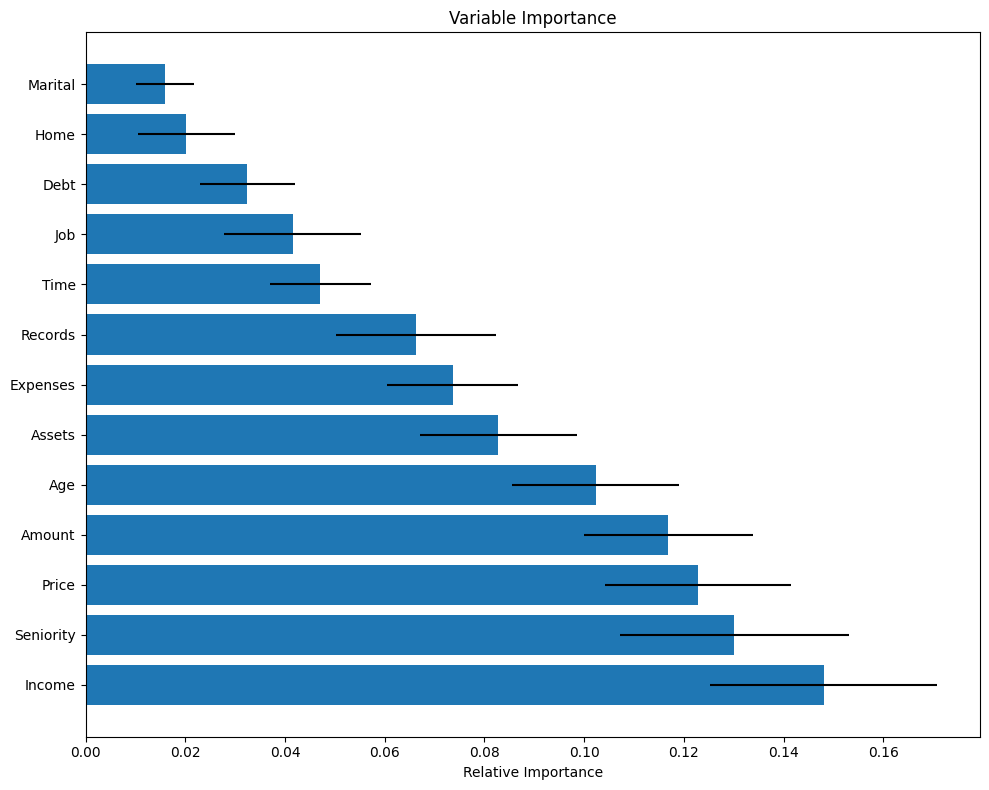

In [26]:
importances, sorted_idx = plot_feature_importance(X_train, Y_train, nom_cols)

### Fonction 2: Sélection du nombre optimal de variables

In [27]:
def select_optimal_features(clf, X_train, Y_train, X_test, Y_test, sorted_idx):
    scores = np.zeros(X_train.shape[1])
    
    for f in range(X_train.shape[1]):
        X_train_f = X_train[:, sorted_idx[:f+1]]
        X_test_f = X_test[:, sorted_idx[:f+1]]
        
        clf.fit(X_train_f, Y_train)
        Y_pred = clf.predict(X_test_f)
        scores[f] = accuracy_score(Y_test, Y_pred)
    
    plt.figure(figsize=(12, 6))
    plt.plot(range(1, len(scores)+1), scores, marker='o')
    plt.xlabel("Nombre de Variables")
    plt.ylabel("Accuracy")
    plt.title("Evolution de l'accuracy en fonction des variables")
    plt.grid(True)
    plt.show()
    
    optimal_n_features = np.argmax(scores) + 1
    print(f"\nNombre optimal de variables: {optimal_n_features}")
    print(f"Meilleure accuracy: {scores[optimal_n_features-1]:.4f}")
    
    return scores, optimal_n_features

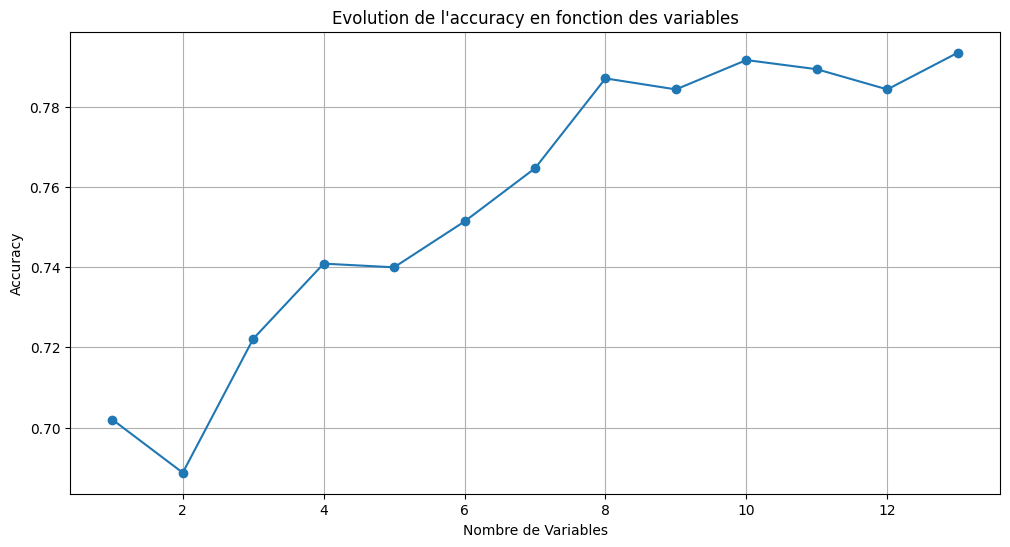


Nombre optimal de variables: 13
Meilleure accuracy: 0.7934


In [28]:
best_algorithm = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
scores, optimal_n = select_optimal_features(
    best_algorithm, X_train, Y_train, X_test, Y_test, sorted_idx
)

### Fonction 3 (BONUS): Explicabilité avec SHAP

EXPLICABILITÉ AVEC SHAP

Importance globale des variables (SHAP):


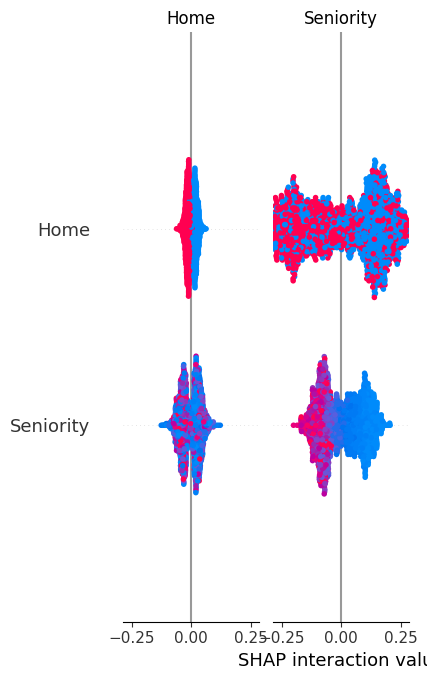


Impact des variables sur les prédictions:


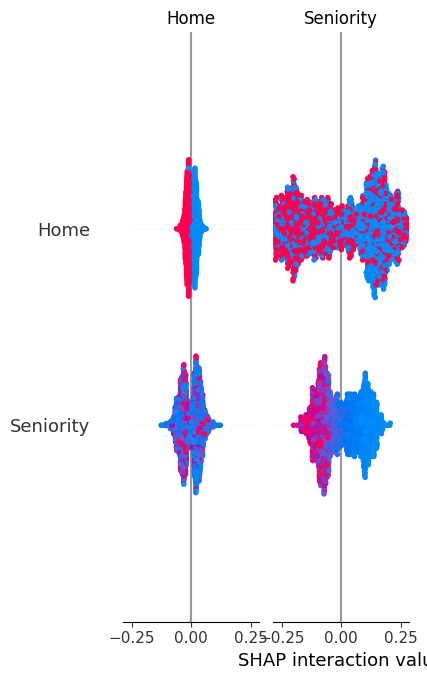

In [29]:
import shap

def explain_with_shap(clf, X_train, X_test, feature_names):
    explainer = shap.TreeExplainer(clf)
    shap_values = explainer.shap_values(X_test)
    
    if isinstance(shap_values, list):
        if len(shap_values) == 2:
            shap_values_to_plot = shap_values[1]
            expected_value = explainer.expected_value[1]
        else:
            shap_values_to_plot = shap_values[1]
            expected_value = explainer.expected_value[1]
    else:
        shap_values_to_plot = shap_values
        expected_value = explainer.expected_value
    
    print("\nImportance globale des variables (SHAP):")
    shap.summary_plot(shap_values_to_plot, X_test, feature_names=feature_names, plot_type="bar")
    
    print("\nImpact des variables sur les prédictions:")
    shap.summary_plot(shap_values_to_plot, X_test, feature_names=feature_names)

print("EXPLICABILITÉ AVEC SHAP")

best_model_for_shap = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
best_model_for_shap.fit(X_train, Y_train)

explain_with_shap(best_model_for_shap, X_train, X_test, nom_cols)

## 9. Création d'un pipeline

In [30]:
def create_pipeline(use_scaler=True, use_pca=False, n_components=3, clf=None, n_features=None):
    from sklearn.feature_selection import SelectKBest, f_classif
    
    steps = []
    
    if use_scaler:
        steps.append(('scaler', StandardScaler()))
    
    if n_features is not None:
        steps.append(('feature_selection', SelectKBest(f_classif, k=n_features)))
    
    if use_pca:
        steps.append(('pca', PCA(n_components=n_components, random_state=SEED)))
    
    if clf is None:
        clf = RandomForestClassifier(n_estimators=200, random_state=SEED, n_jobs=-1)
    steps.append(('classifier', clf))
    
    pipeline = Pipeline(steps)
    
    return pipeline

In [31]:
print("CRÉATION DU PIPELINE FINAL")

final_pipeline = create_pipeline(
    use_scaler=True,
    use_pca=False,
    clf=RandomForestClassifier(**best_params_rf, random_state=SEED, n_jobs=-1),
    n_features=optimal_n
)

final_pipeline.fit(X_train, Y_train)

Y_pred_final = final_pipeline.predict(X_test)
final_accuracy = accuracy_score(Y_test, Y_pred_final)
final_precision = precision_score(Y_test, Y_pred_final, average='weighted', zero_division=0)
final_score = (final_accuracy + final_precision) / 2

print(f"\nPerformance du pipeline final:")
print(f"Accuracy: {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Score final: {final_score:.4f}")

CRÉATION DU PIPELINE FINAL

Performance du pipeline final:
Accuracy: 0.7843
Precision: 0.7799
Score final: 0.7821


In [32]:
pipeline_filename = 'credit_scoring_pipeline.pkl'

with open(pipeline_filename, 'wb') as f:
    pickle.dump(final_pipeline, f)

print(f"\nPipeline sauvegardé dans: {pipeline_filename}")

with open(pipeline_filename, 'rb') as f:
    loaded_pipeline = pickle.load(f)

Y_pred_loaded = loaded_pipeline.predict(X_test)
assert np.array_equal(Y_pred_final, Y_pred_loaded), "Erreur: les prédictions ne correspondent pas!"
print("Pipeline chargé et vérifié avec succès!")


Pipeline sauvegardé dans: credit_scoring_pipeline.pkl
Pipeline chargé et vérifié avec succès!


## Conclusion et résumé des résultats

In [33]:
print("RÉSUMÉ DU TP - APPRENTISSAGE SUPERVISÉ")
print("\n1. CHARGEMENT DES DONNÉES")
print(f"   - Nombre d'exemples: {X.shape[0]}")
print(f"   - Nombre de variables: {X.shape[1]}")
print(f"   - Split train/test: 50/50")

print("\n2. ALGORITHMES TESTÉS")
for clf_name in clfs.keys():
    print(f"   - {clf_name}")

print("\n3. PRÉPARATION DES DONNÉES")
print("   - Données originales")
print("   - Données normalisées (StandardScaler)")
print("   - Données avec ACP (3 composantes)")

print("\n4. VALIDATION CROISÉE")
print("   - 10-fold cross-validation")
print("   - Score: (accuracy + precision) / 2")

print("\n5. OPTIMISATION")
print("   - GridSearchCV pour tuning des hyperparamètres")
print("   - Sélection de variables par importance")

print("\n6. PIPELINE FINAL")
print(f"   - Score final: {final_score:.4f}")
print(f"   - Sauvegardé dans: {pipeline_filename}")

RÉSUMÉ DU TP - APPRENTISSAGE SUPERVISÉ

1. CHARGEMENT DES DONNÉES
   - Nombre d'exemples: 4375
   - Nombre de variables: 13
   - Split train/test: 50/50

2. ALGORITHMES TESTÉS
   - CART
   - ID3
   - MLP
   - KNN
   - Bagging
   - AdaBoost
   - RandomForest

3. PRÉPARATION DES DONNÉES
   - Données originales
   - Données normalisées (StandardScaler)
   - Données avec ACP (3 composantes)

4. VALIDATION CROISÉE
   - 10-fold cross-validation
   - Score: (accuracy + precision) / 2

5. OPTIMISATION
   - GridSearchCV pour tuning des hyperparamètres
   - Sélection de variables par importance

6. PIPELINE FINAL
   - Score final: 0.7821
   - Sauvegardé dans: credit_scoring_pipeline.pkl
